In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
%load_ext autoreload
%autoreload 2

import json, feos, si_units as si, numpy as np, importlib.metadata
import thermoift.PLOT_SETTINGS as ps
from thermoift import KIJ
from pathlib import Path
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine
)
from thermoift.semi_emperical_correlations import semi_emperical_correlations
from IPython.display import display

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=f6e6271a58f03ad28b174e11eede7e11b3f3bd6464010062c189195988426a95
  Stored in directory: /tmp/pip-ephem-wheel-cache-ae650d9u/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
FEOS version u

## Cell 2: PARAMETER tag Cell

In [2]:
SLURM_RUN                       = False
FEED_INDEX                      = 0
verbose                         = False
CSV_FOLDER                      = "CSV"
PLOT_FOLDER                     = "PLOTS"
CRITICAL_REGION_ENHANCEMENTS    = False  # Keep critical-region T-grid meshing disabled
IFT_CONTOUR_PLOT_ENHANCEMENTS         = False  # Keep interfacial tension contour plot meshing disabled


In [3]:
# Parameters
FEED_INDEX = 0
SLURM_RUN = False
verbose = False
CSV_FOLDER = "LOCAL_RUN/0/CSV"
PLOT_FOLDER = "LOCAL_RUN/0/PLOTS"
CRITICAL_REGION_ENHANCEMENTS = True
IFT_CONTOUR_PLOT_ENHANCEMENTS = True


In [4]:
if SLURM_RUN == False:
    T_initial   = 200
    P_TOL       = 1e-1          # Pressure [bar] tolerance for flash calculations
    T_STEP      = 5             # Temperature step in [K] for bubble/dew curves computation
    cDFT_NP     = 3             # Number of pressure points between P_dew and P_bubble per isotherm
    lgrid       = 100           # Length of computational domain [Angstrom]
    ngrid       = 2048           # Number of grid points for planar interface

elif SLURM_RUN == True:
    T_initial   = 200
    P_TOL       = 1e-4
    T_STEP      = 1
    cDFT_NP     = 5
    lgrid       = 100
    ngrid       = 2048

#-------- Dynamic-grid retry settings ------
# Normal calculations use the fixed lgrid/ngrid above. If the interface solve
# fails, retry once with a larger lgrid/ngrid from thermoift dynamic scaling.
RETRY_DYNAMIC_GRID_ON_FAILURE = True
dynamic_lgrid                = True     # Scale lgrid on retry: l_grid * (1 - T/Tc)^{-0.5}
dynamic_ngrid                = True     # Scale ngrid by the same factor as lgrid on retry
dynamic_scale_max            = 10.0     # Maximum scale factor cap for dynamic_lgrid/dynamic_ngrid
# Retry scale is min(max(1.0, (1.0 - T_K / Tc_K)**(-0.5)), dynamic_scale_max).
# With lgrid=100 and ngrid=2048, the retry mesh is capped at lgrid=1000 and ngrid=20480.
near_crit_power              = 1.5      # No T-grid clustering unless CRITICAL_REGION_ENHANCEMENTS is enabled

## Cell 3: Load the feed componenets and their compositions from the CSV file

In [5]:
csv_path         = "../../CSV_feeds/Combined_compositions.csv"
COMPONENTS       = RegistryManager.map_csv_to_components()
all_compositions = CompositionHandler.load_compositions(csv_path, n=100).tolist()

# Select composition(s) based on FEED_INDEX from the parameter cell above.
if FEED_INDEX is not None:
    if FEED_INDEX < 0 or FEED_INDEX >= len(all_compositions):
        raise IndexError(f"FEED_INDEX={FEED_INDEX} is out of range for {len(all_compositions)} compositions")
    compositions = [all_compositions[FEED_INDEX]]
    print(f"Running single composition at CSV row index {FEED_INDEX} (item {FEED_INDEX + 1})")
else:
    compositions = all_compositions[:1]
    print("Running first 1 composition (local mode)")

print(f"Loaded {len(compositions)} composition(s) from {csv_path}")
print(f"COMPONENTS: {COMPONENTS}")
print()
print("Composition(s):")
for i, comp in enumerate(compositions):
    label = FEED_INDEX if FEED_INDEX is not None else i
    print(f"  CSV row {label}: {comp}")

Running single composition at CSV row index 0 (item 1)
Loaded 1 composition(s) from ../../CSV_feeds/Combined_compositions.csv
COMPONENTS: ['carbon dioxide', 'hydrogen', 'argon', 'nitrogen', 'methane', 'oxygen', 'carbon monoxide', 'hydrogen sulfide']

Composition(s):
  CSV row 0: [0.97, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03, 0.0]


## Cell 4: Settings, KIJ Models, and Feeds

Loaded KIJ models from ../../CSV_feeds/KIJ_pairs.json
Active components (non-zero in at least one feed): ['carbon dioxide', 'carbon monoxide']

K(300.0 K) =
[[ 0.         -0.04790297]
 [-0.04790297  0.        ]]

Symbolic K(T) matrix:


Matrix([
[                0, 0.0009*T - 0.3135],
[0.0009*T - 0.3135,                 0]])


Pair equations:


Eq(k_{CO2,CO}(T), 0.0009*T - 0.3135)

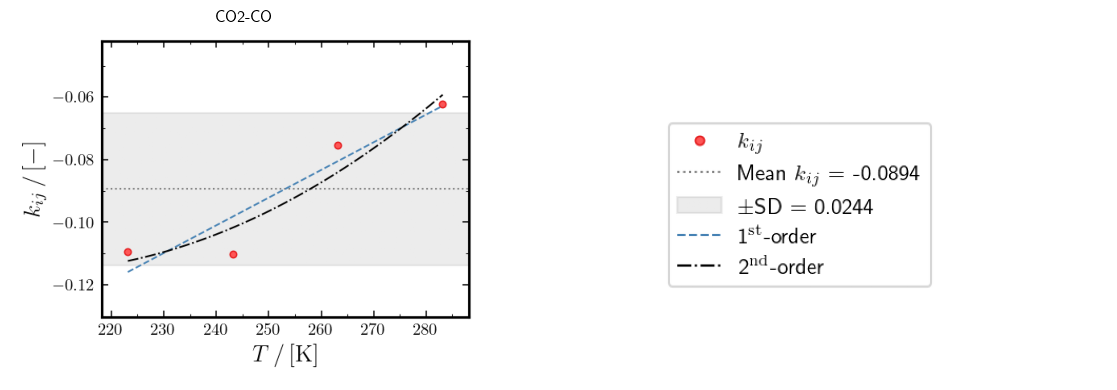

|component|molarweight|m|sigma|epsilon_k|q|
|-|-|-|-|-|-|
|carbon dioxide|44.01|1.6298|3.0867|163.34|3.9546|
|carbon monoxide|27.995|1.32286|3.24532|91.17087||

|component 1|component 2|k_ij|
|-|-|-|
|carbon dioxide|carbon monoxide|-0.047902974581342406|

In [6]:
KIJ_PAIRS_FILE = Path("../../CSV_feeds/KIJ_pairs.json")
KIJ_LABELS     = RegistryManager.kij_labels_from_names(COMPONENTS)

with open(KIJ_PAIRS_FILE) as f:
    kij_overrides = json.load(f)

KIJ_map = ParameterBuilder.build_kij_map(KIJ_LABELS, kij_overrides)
print(f"Loaded KIJ models from {KIJ_PAIRS_FILE}")

feeds = CompositionHandler.make_feeds(*compositions)
ACTIVE_COMPONENTS, ACTIVE_KIJ_LABELS, active_map = CompositionHandler.active_components_from_feeds(
    feeds, COMPONENTS, KIJ_map)
print(f"Active components (non-zero in at least one feed): {ACTIVE_COMPONENTS}")

builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
parameters = ParameterBuilder.build_parameters(ACTIVE_COMPONENTS, T_K=300.0, kij_builder=builder, model_map=active_map)
components = RegistryManager.get_component_names(parameters)
builder.build_and_display(components=ACTIVE_KIJ_LABELS, model_map=active_map, T_eval=300.0,
                          show_matrix=True, show_pair_equations=True)
builder.show_pair_plots(ACTIVE_KIJ_LABELS, mode="all")

parameters

## Cell 5: Phase envelope computation, PT diagram, VLE_DFT initialization, and envelope CSV export

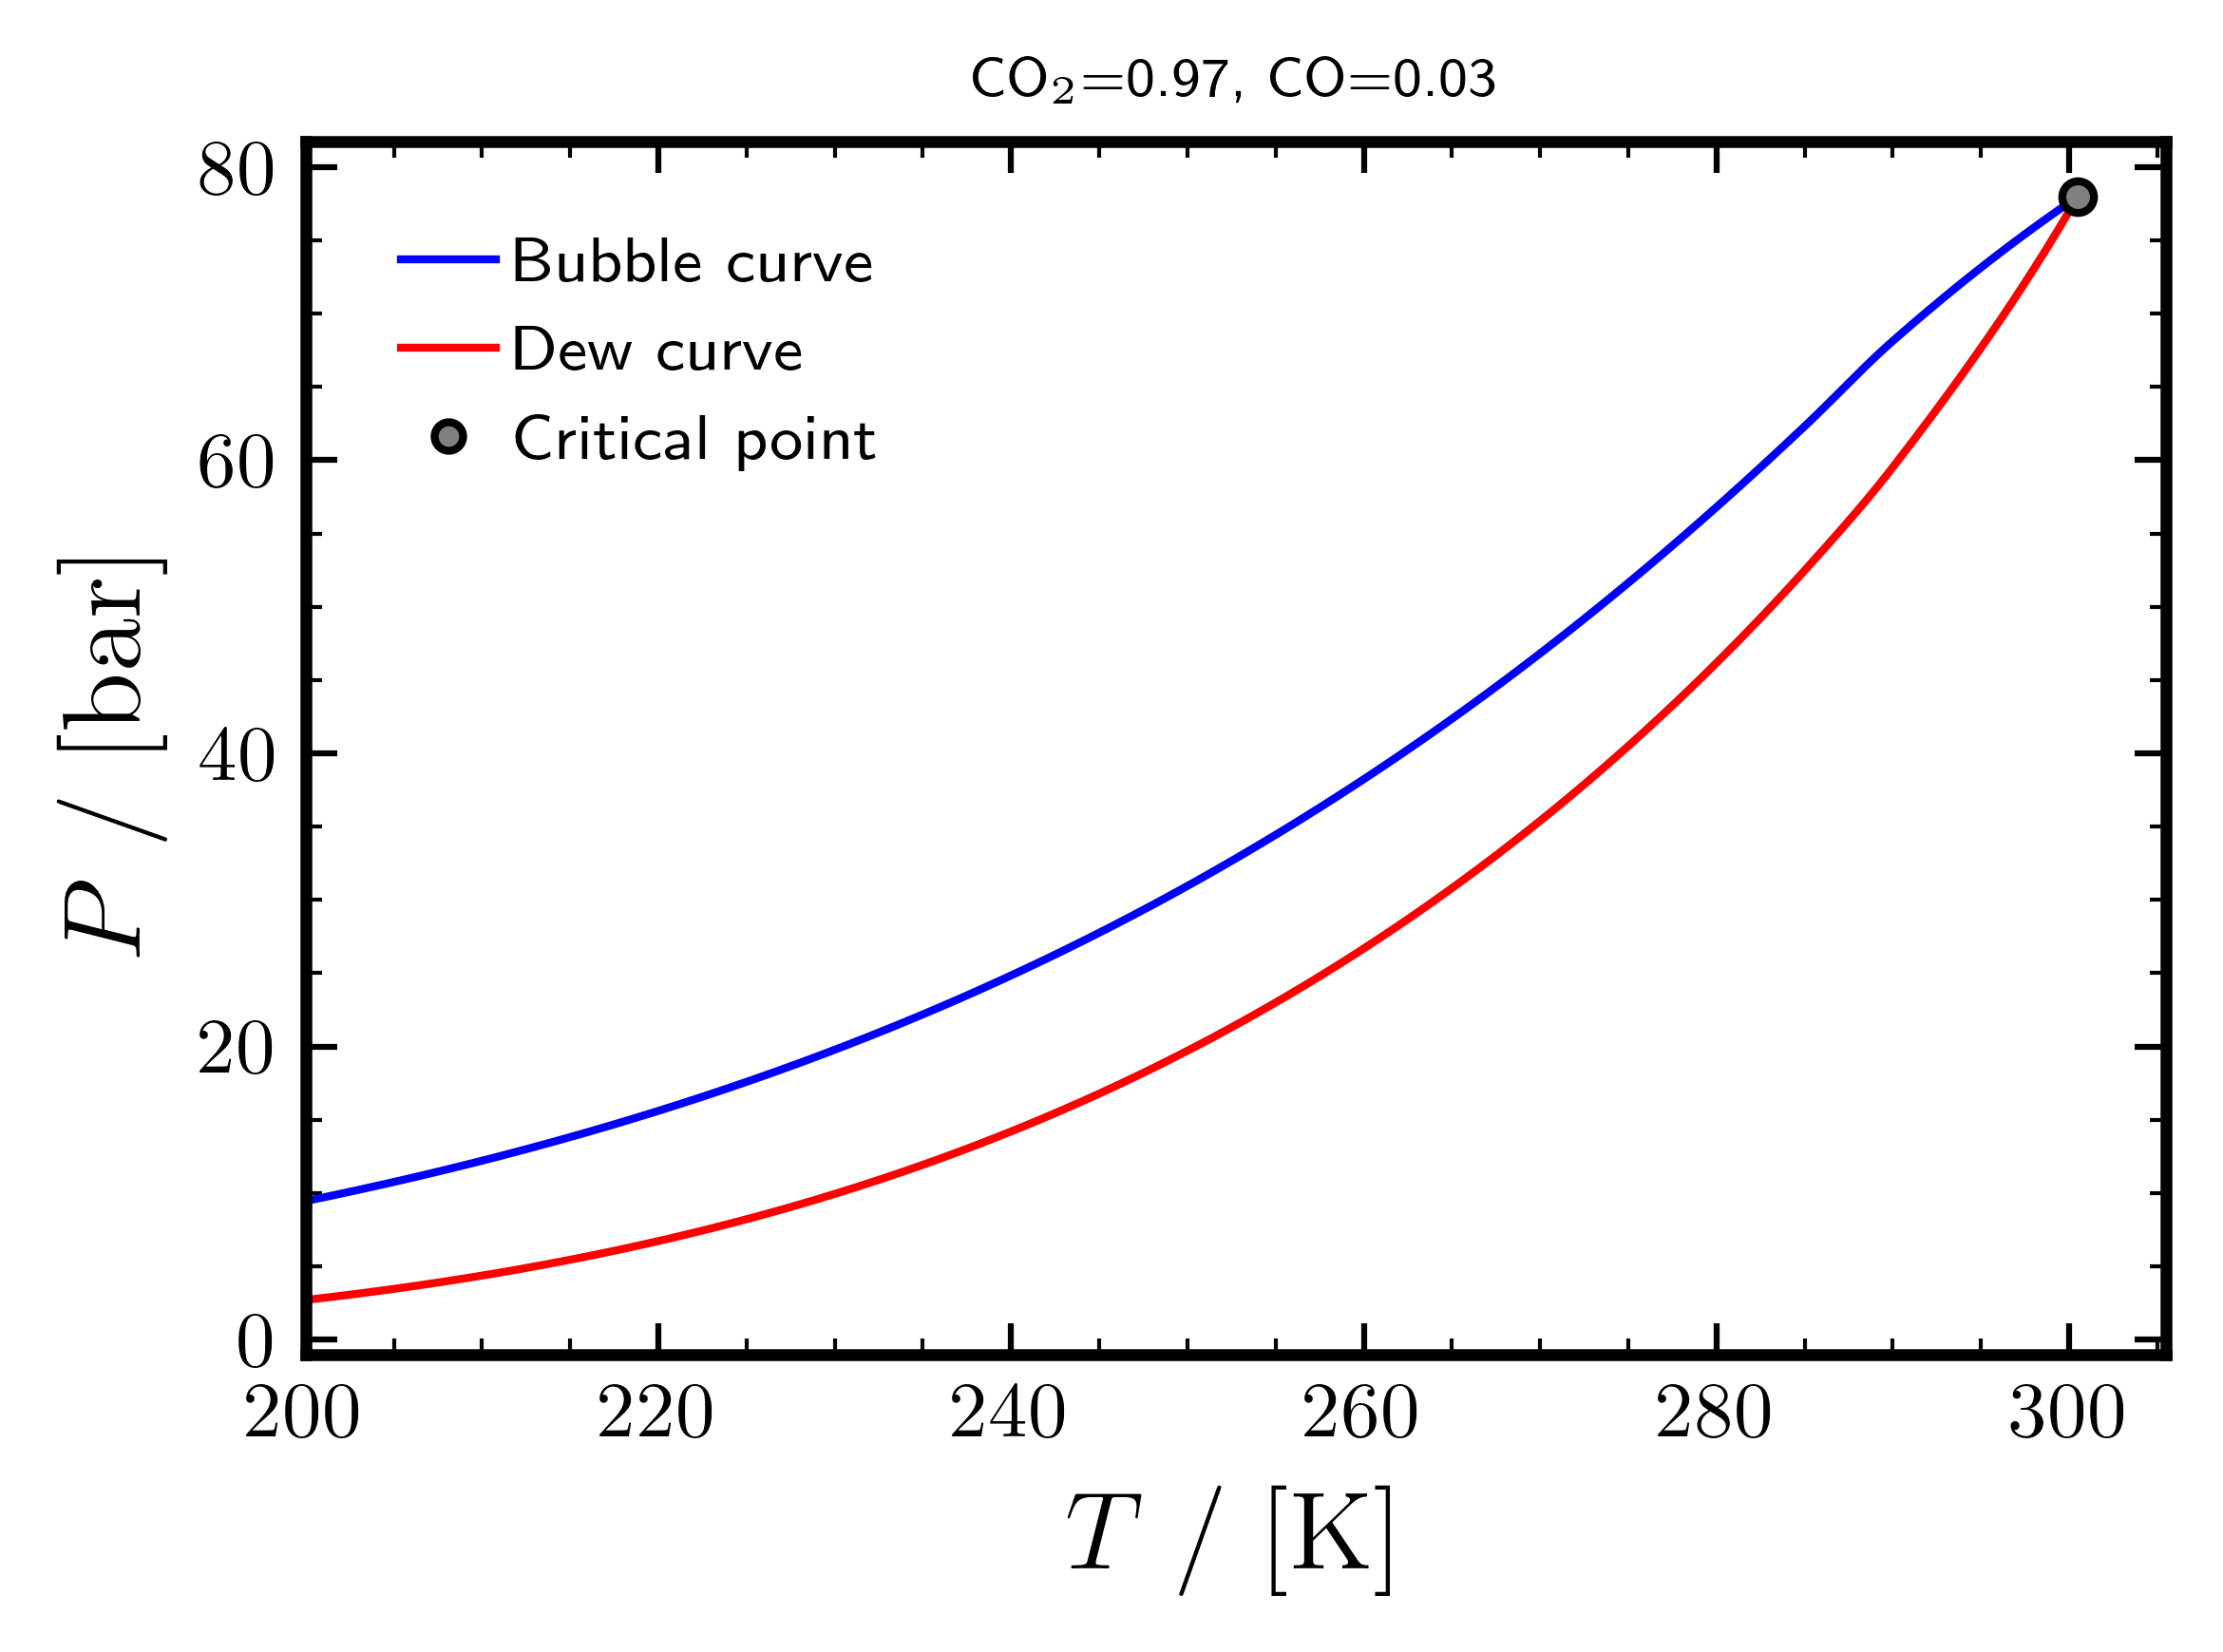

In [7]:
PT_results = {}
PT_figs    = {}
VLE_DFT    = {}
_pt_data   = {}

# --- Phase envelope ---
for k, z in enumerate(feeds, start=1):
    z    = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)

    if verbose:
        print(f"\nFeed {k}: z = {z}")

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    feed_map    = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    parameters_ref = ParameterBuilder.build_parameters(
        active_components, T_K=T_initial, kij_builder=builder, model_map=feed_map)
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)

    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial)

        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")

        Tc_K     = float(CT / si.KELVIN)
        Pc_bar   = float(CP / si.BAR)
        eos_fn   = VLECalculator.make_eos_factory(active_components, builder, feed_map)
        T_values = np.arange(T_initial, Tc_K, T_STEP)

        T_bubble_all, P_bubble_all, T_dew_all, P_dew_all = VLECalculator.compute_phase_envelope(
            eos_fn, T_values, active_feed, verbose, Tc=Tc_K, Pc=Pc_bar)

        PT_results[f"feed_{k}"] = {
            "z":      [float(x) for x in np.asarray(z, dtype=float)],
            "active_z": [float(x) for x in np.asarray(active_z, dtype=float)],
            "active_components": list(active_components),
            "TC_K":   round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }

    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("Critical point computation failed:", e)

# --- PT diagram, VLE_DFT init, and envelope CSV ---
for feed_key, feed in PT_results.items():
    TP_z = np.array(feed.get("z", []))
    CT   = feed["TC_K"] * si.KELVIN
    CP   = feed["PC_bar"] * si.BAR

    fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, parameters)
    PlottingEngine.save_plots(fig, f"PT_{feed_key}", folder=CSV_FOLDER)
    PT_figs[feed_key] = (fig, ax)

    common_T, P_bub_at, P_dew_at = DataProcessor.extract_common_envelope(feed)

    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": float(p["T_K"]), "P_bar": float(p["P_bar"])} for p in sorted(feed.get("bubble", []), key=lambda p: p["T_K"])],
            "dew_curve":    [{"T_K": float(p["T_K"]), "P_bar": float(p["P_bar"])} for p in sorted(feed.get("dew",    []), key=lambda p: p["T_K"])],
            "isothermal_lines": [
                {"T_K": float(T), "P_bubble_bar": float(Pb), "P_dew_bar": float(Pd)}
                for T, Pb, Pd in zip(common_T, P_bub_at, P_dew_at) if Pb > Pd
            ]
        },
        "interfacial_data": {}
    }
    _pt_data[feed_key] = {
        "CT": CT, "CP": CP, "TP_z": TP_z,
        "common_T": common_T, "P_bub_at": P_bub_at, "P_dew_at": P_dew_at,
    }

    DataProcessor.export_to_csv(
        {feed_key: VLE_DFT[feed_key]},
        folder=CSV_FOLDER,
        verbose=verbose,
        filename_interfacial=None,
        filename_envelope=f"{feed_key}_envelope",
    )

    if verbose:
        print(f"\n{feed_key}: {len(common_T)} isothermal flash temperatures")

## Cell 7: TP flash and cDFT interfacial tension calculations

Surface tension calculation failed at T = 283.2 K, P = 60.23 bar with base grid: `DFT` did not converge within the maximum number of iterations.
Dynamic-grid retry succeeded at T = 283.2 K, P = 60.23 bar
Surface tension calculation failed at T = 286.6 K, P = 54.88 bar with base grid: `DFT` did not converge within the maximum number of iterations.
Dynamic-grid retry succeeded at T = 286.6 K, P = 54.88 bar
Surface tension calculation failed at T = 286.6 K, P = 59.50 bar with base grid: `DFT` did not converge within the maximum number of iterations.
Dynamic-grid retry succeeded at T = 286.6 K, P = 59.50 bar
Surface tension calculation failed at T = 286.6 K, P = 64.11 bar with base grid: `Euler-Lagrange equation` encountered illegal values during the iteration.
Dynamic-grid retry succeeded at T = 286.6 K, P = 64.11 bar
Surface tension calculation failed at T = 290.0 K, P = 59.62 bar with base grid: `DFT` did not converge within the maximum number of iterations.
Dynamic-grid retry succeeded

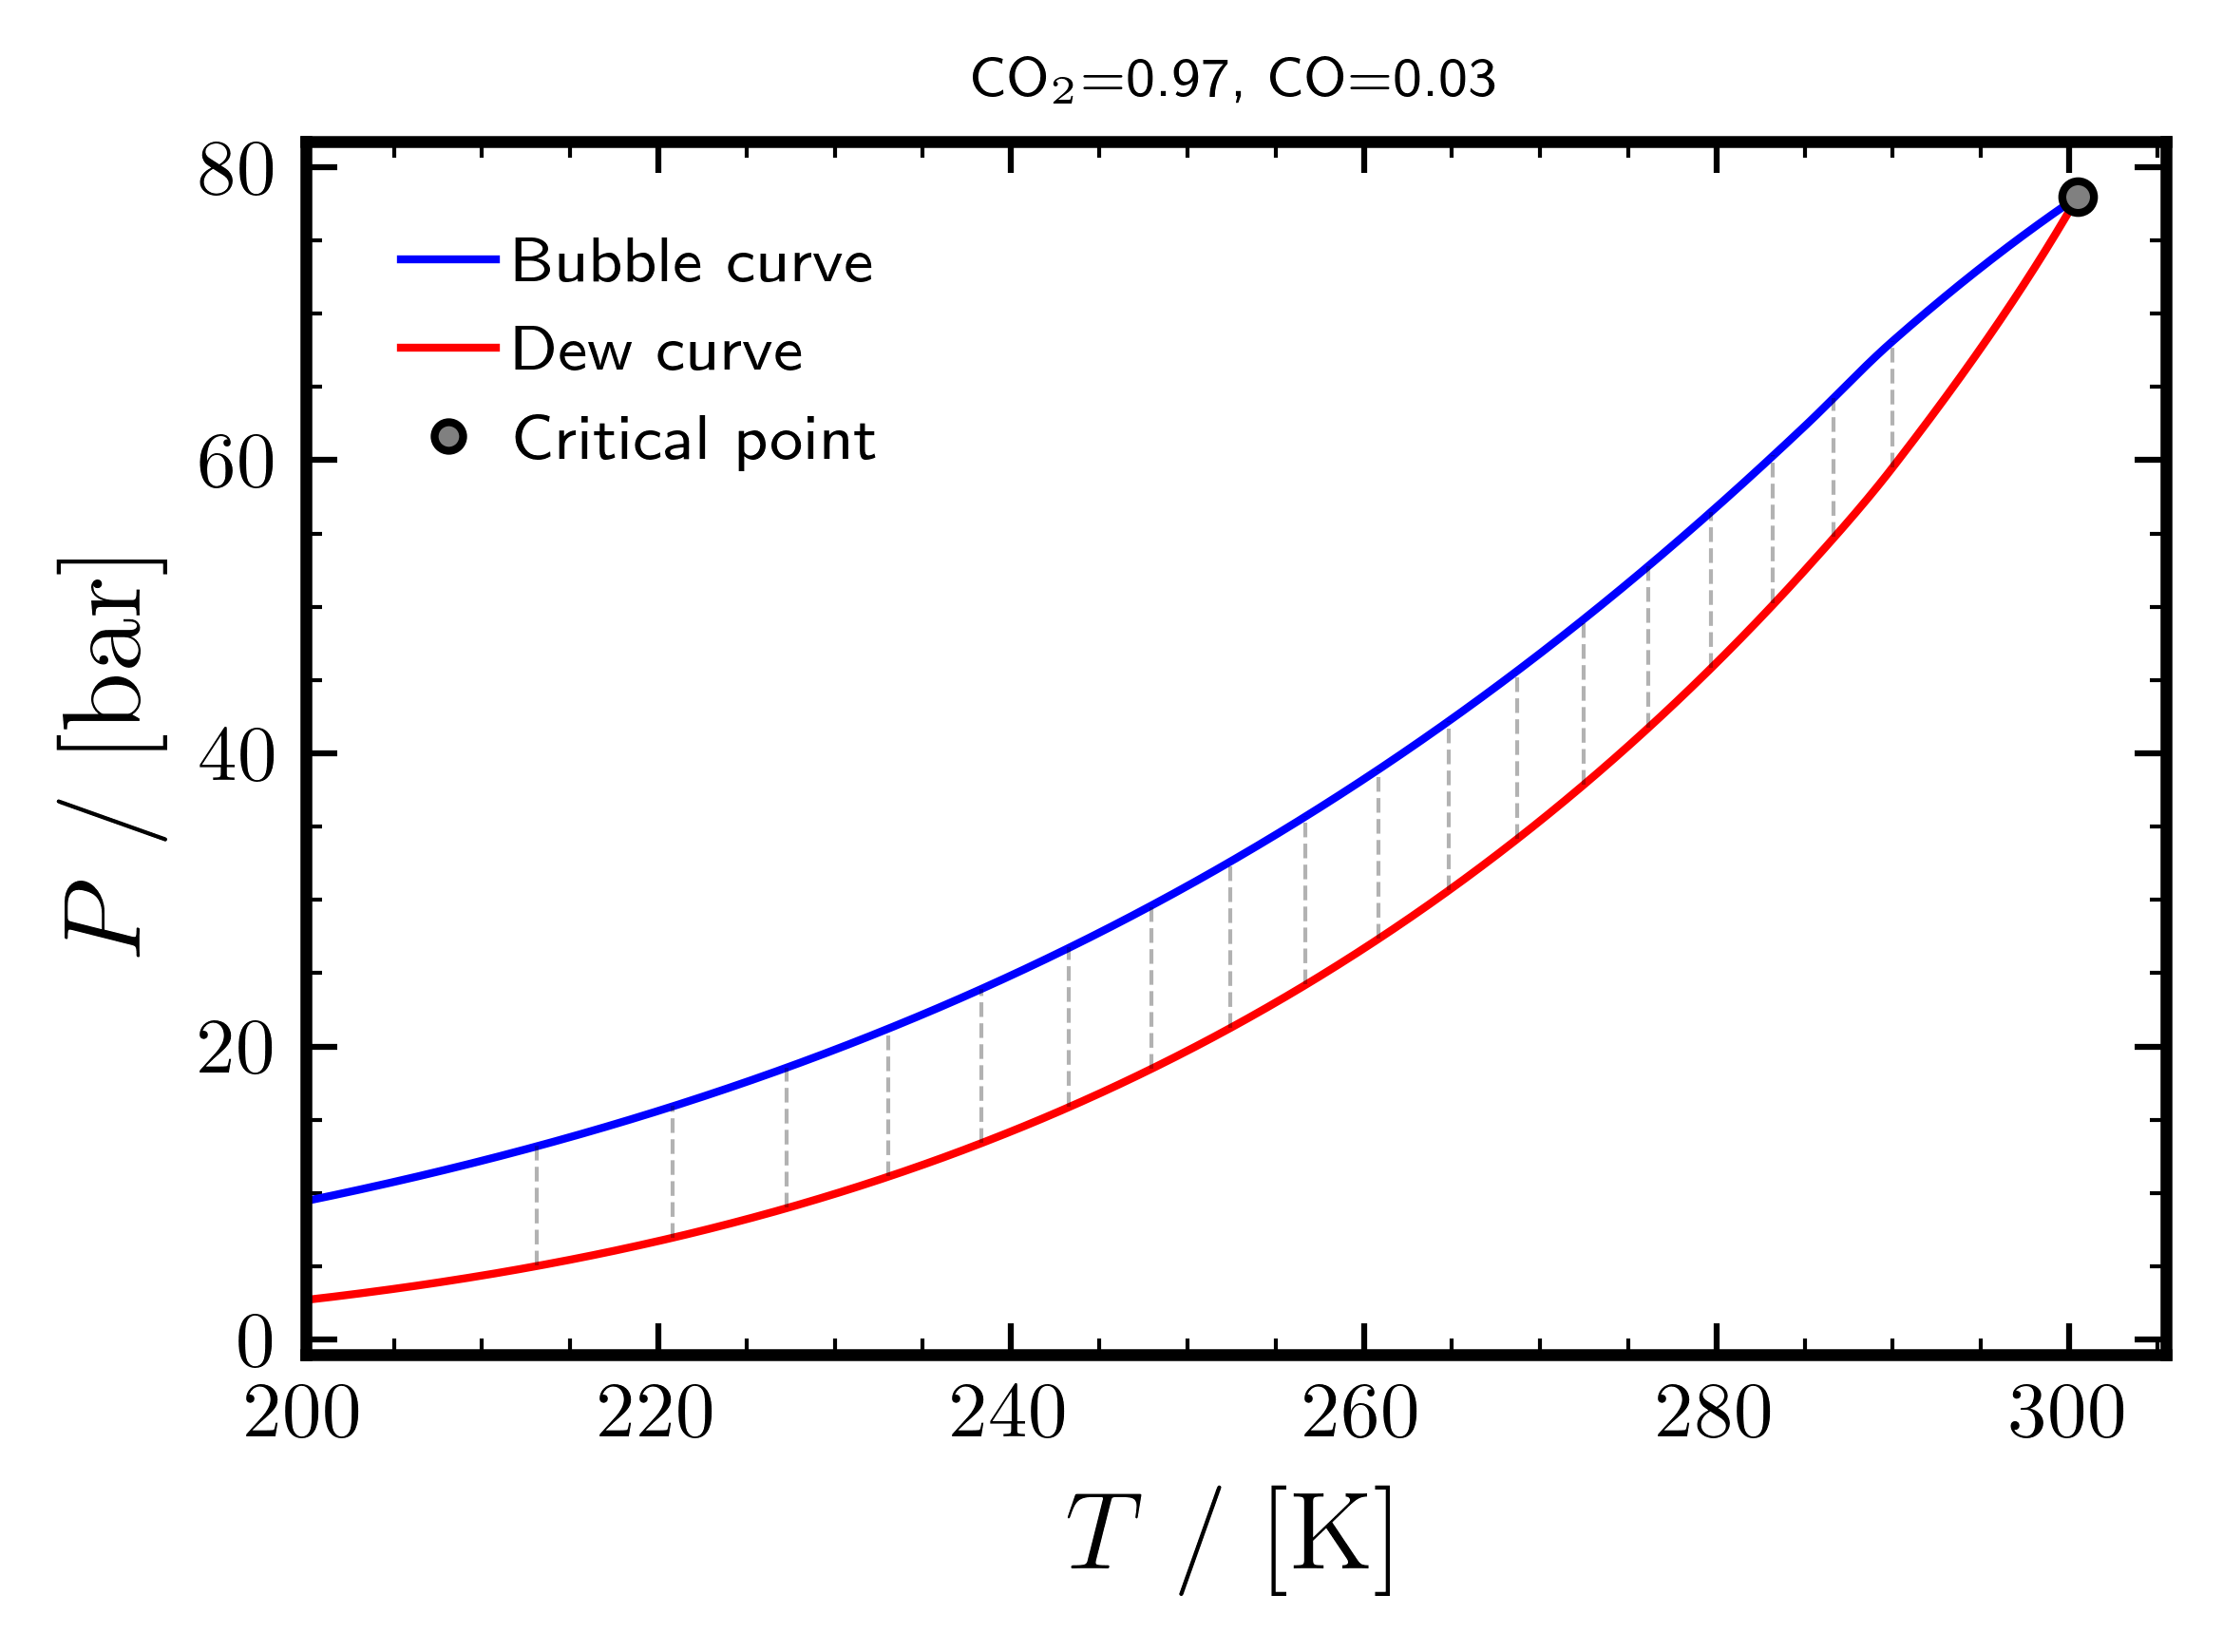

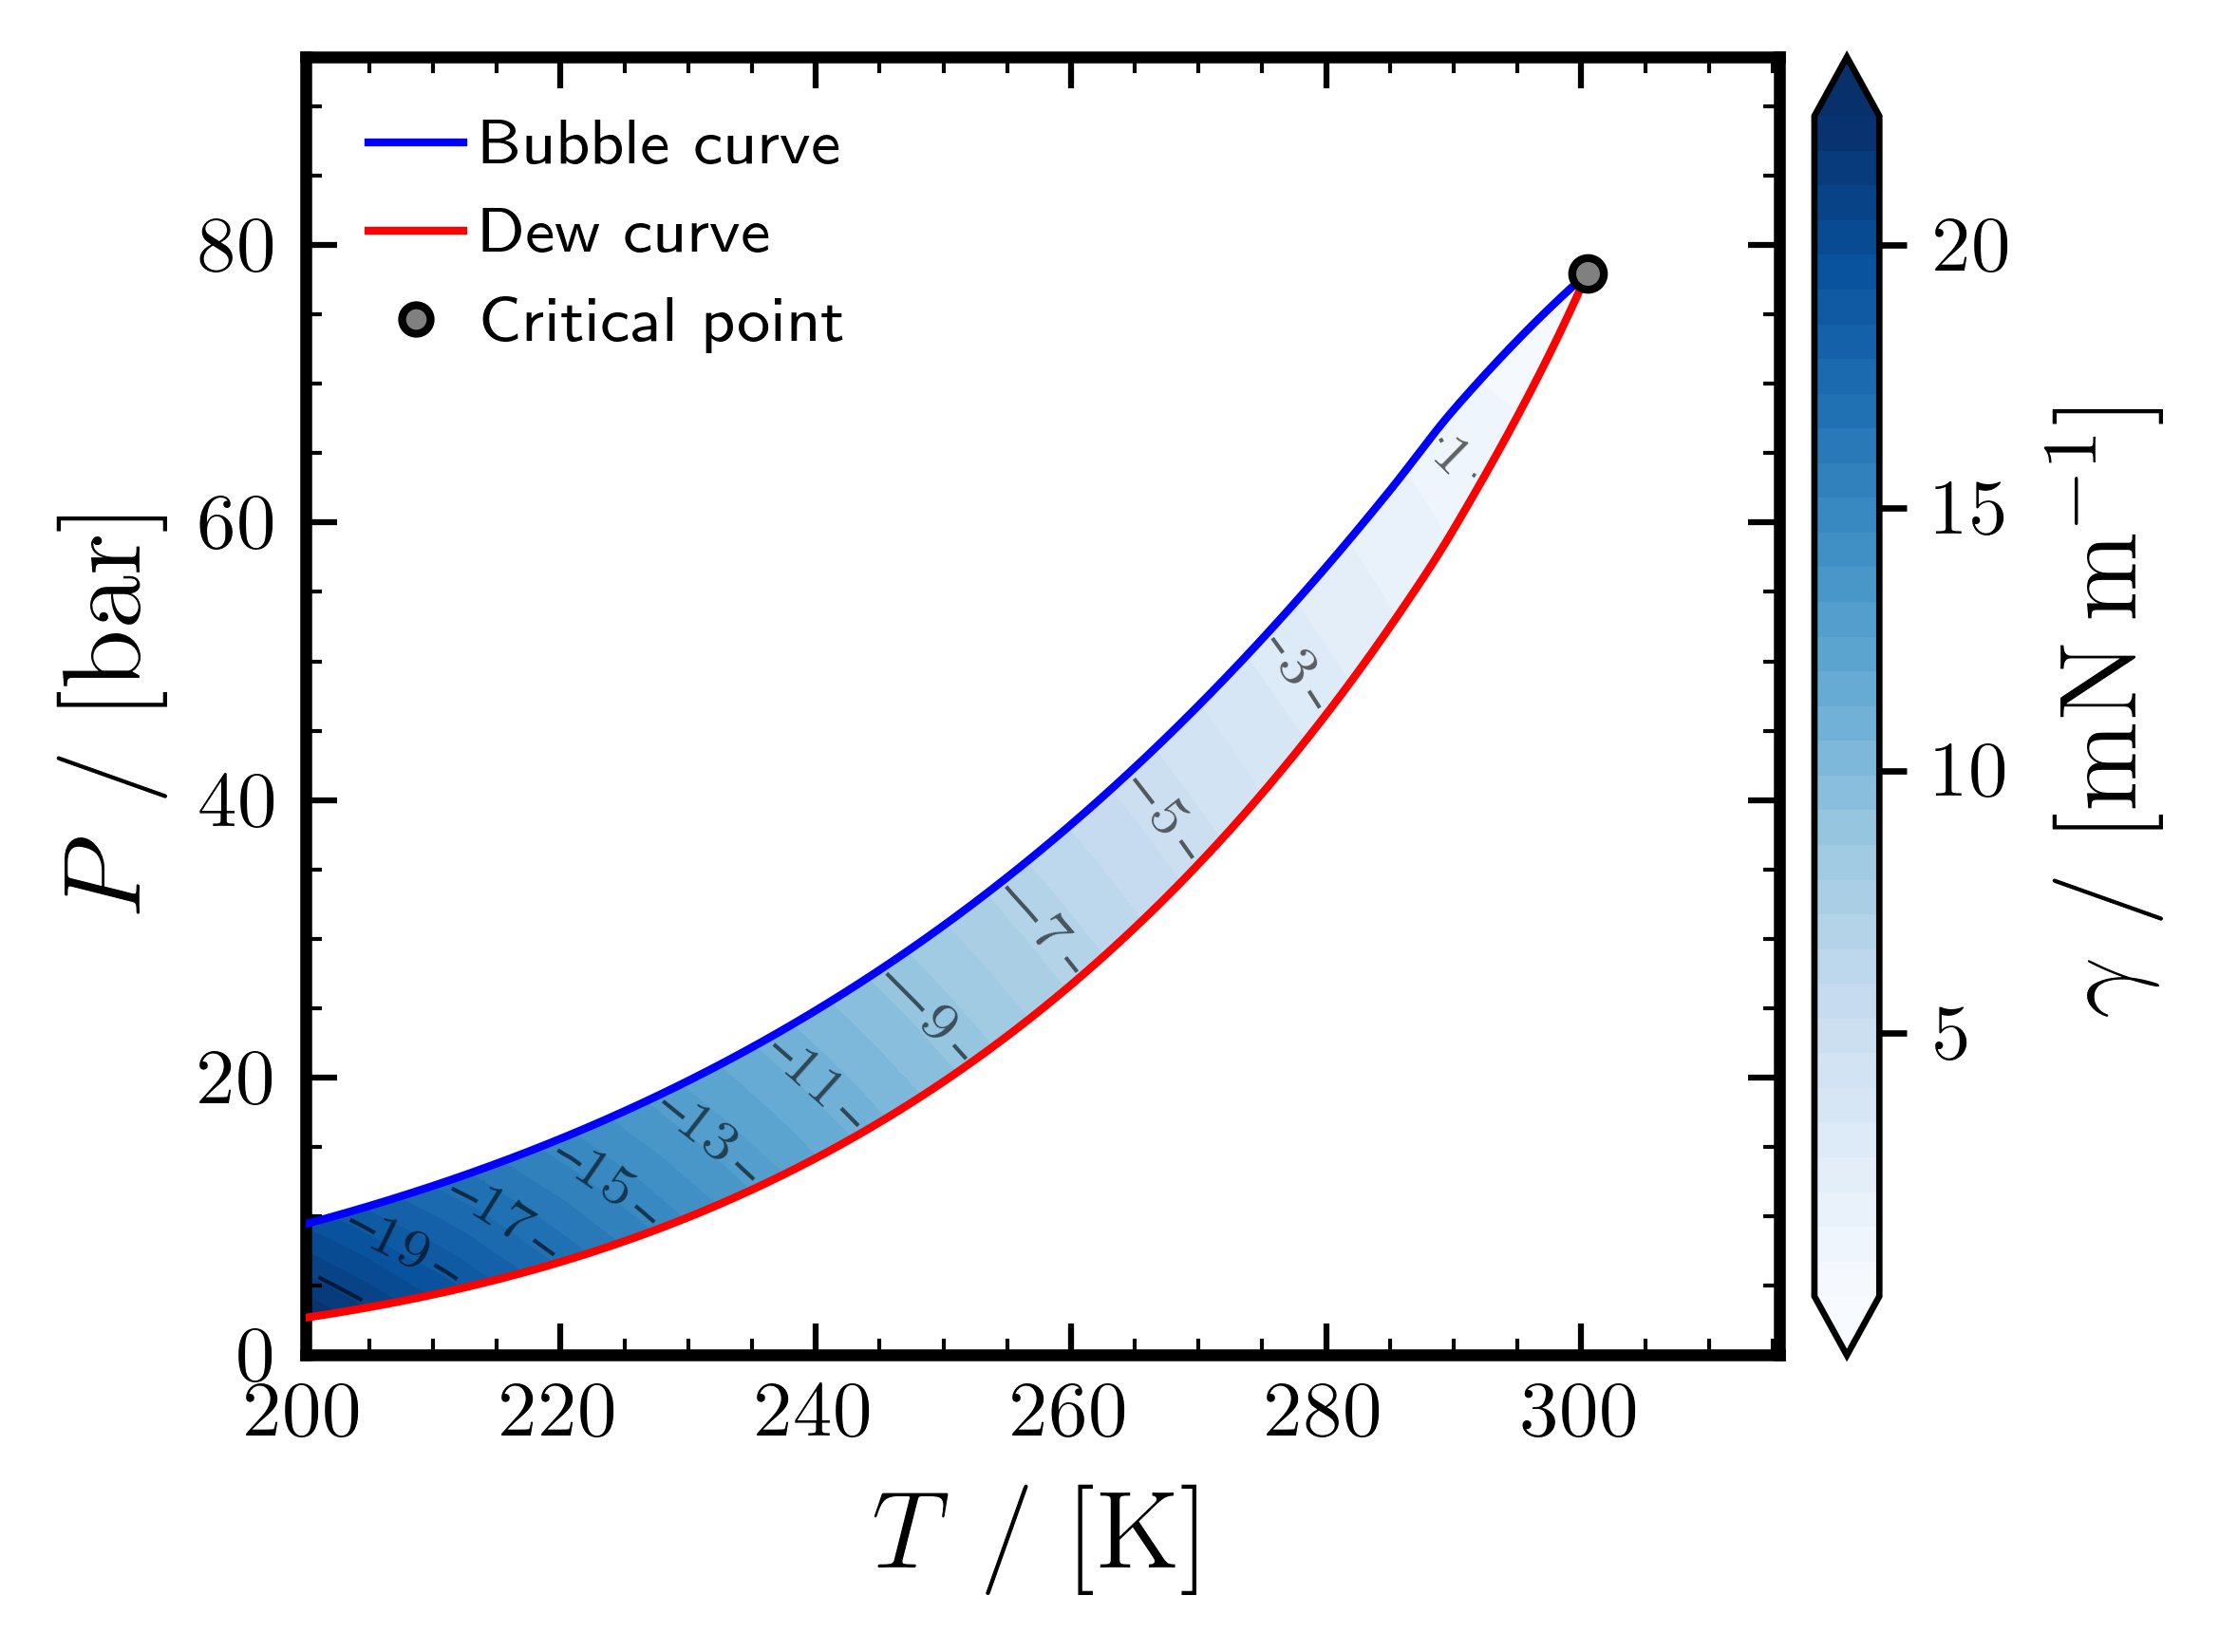

In [8]:
# Pure-component reference cDFT uses semi_emperical_correlations. If a base-grid pure CO2 solve fails,
# thermoift retries once with dynamically enlarged lgrid/ngrid before returning NaN.
if CRITICAL_REGION_ENHANCEMENTS:
    sec = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid, dynamic_lgrid=dynamic_lgrid,
                                  dynamic_ngrid=dynamic_ngrid, max_scale=dynamic_scale_max)
else:
    sec = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)
        
for feed_key, feed in PT_results.items():
    fig, ax  = PT_figs[feed_key]
    meta     = _pt_data[feed_key]
    CT, CP   = meta["CT"], meta["CP"]
    TP_z     = meta["TP_z"]
    common_T = list(meta["common_T"])
    P_bub_at = list(meta["P_bub_at"])
    P_dew_at = list(meta["P_dew_at"])

    Tc_K = float(CT / si.KELVIN)

    # Apply power-law T-grid clustering near Tc (near_crit_power=1.0 - no change)
    if CRITICAL_REGION_ENHANCEMENTS:
        if near_crit_power != 1.0 and len(common_T) > 2:
            T_min_c  = float(common_T[0])
            T_max_c  = float(common_T[-1])
            t_biased = np.linspace(0.0, 1.0, len(common_T)) ** (1.0 / near_crit_power)
            T_biased = T_min_c + t_biased * (T_max_c - T_min_c)
            P_bub_at = np.interp(T_biased, common_T, P_bub_at).tolist()
            P_dew_at = np.interp(T_biased, common_T, P_dew_at).tolist()
            common_T = T_biased.tolist()

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        TP_z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    feed_map    = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    if verbose:
        print(f"\n{feed_key}:")

    for T_K, P_b, P_d in zip(common_T, P_bub_at, P_dew_at):
        if P_b <= P_d:
            continue

        parameters_T = ParameterBuilder.build_parameters(
            active_components, T_K=float(T_K), kij_builder=builder, model_map=feed_map)
        eos_T        = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
        molar_masses = PropertyCalculator.molar_masses(parameters_T)

        gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
            sec._pure_component_cDFT("carbon dioxide", float(T_K))

        pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, cDFT_NP)
        ax.plot([T_K, T_K], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)
        VLE_DFT[feed_key]["interfacial_data"][T_K] = []

        if verbose:
            print(f"  T = {T_K:.1f} K: P_bub = {P_b:.2f}, P_dew = {P_d:.2f} bar")

        for P in pressures:
            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} | z = {active_z}")

            try:
                eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                    eos_T, T_K*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
            except Exception as e:
                print(f"TP flash failed for z = {active_z} at T = {T_K:.1f} K, P = {P:.2f} bar: {e}")
                continue

            interface = InterfacialTensionCalculator.build_planar_interface(eq,
                critical_temperature=CT, n_grid=ngrid, l_grid=lgrid,
                T_K=float(T_K), Tc_K=Tc_K)

            try:
                gamma_mN_m, interfacial_thickness_nm, enrichment = (
                    InterfacialTensionCalculator.solve_interface_properties(interface)
                )
            except Exception as e:
                print(f"Surface tension calculation failed at T = {T_K:.1f} K, P = {P:.2f} bar with base grid: {e}")

                if RETRY_DYNAMIC_GRID_ON_FAILURE:
                    try:
                        retry_interface = InterfacialTensionCalculator.build_planar_interface(eq,
                            critical_temperature=CT, n_grid=ngrid, l_grid=lgrid,
                            T_K=float(T_K), Tc_K=Tc_K, dynamic_lgrid=dynamic_lgrid,
                            dynamic_ngrid=dynamic_ngrid, max_scale=dynamic_scale_max)
                        gamma_mN_m, interfacial_thickness_nm, enrichment = (
                            InterfacialTensionCalculator.solve_interface_properties(retry_interface)
                        )
                        print(f"Dynamic-grid retry succeeded at T = {T_K:.1f} K, P = {P:.2f} bar")
                    except Exception as retry_error:
                        print(f"Dynamic-grid retry failed at T = {T_K:.1f} K, P = {P:.2f} bar: {retry_error}")
                        gamma_mN_m               = np.nan
                        interfacial_thickness_nm = np.nan
                        enrichment               = tuple(np.nan for _ in active_components)
                else:
                    gamma_mN_m               = np.nan
                    interfacial_thickness_nm = np.nan
                    enrichment               = tuple(np.nan for _ in active_components)

            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

            row_data = DataProcessor.assemble_row(
                T_K, P, active_z, CT, CP, P_b, P_d, liquid_density, vapor_density,
                x, y, gamma_mN_m, interfacial_thickness_nm, active_components, enrichment,
                gamma0_CO2=gamma0_CO2,
                rhoL0_CO2_mol_cm3=rhoL0_CO2,
                rhoV0_CO2_mol_cm3=rhoV0_CO2,
                Tc_CO2=Tc_CO2,
                Psat_CO2=Psat_CO2,
                ML_mode=True)

            VLE_DFT[feed_key]["interfacial_data"][T_K].append(row_data)

    PlottingEngine.save_plots(fig, f"PT_mesh_{feed_key}", folder=CSV_FOLDER)
    display(fig)

    fig_gamma = PlottingEngine.plot_interfacial_tension_map(
        PT_results, VLE_DFT, feed_key, parameters,
        enhanced=IFT_CONTOUR_PLOT_ENHANCEMENTS)
    if fig_gamma is not None:
        PlottingEngine.save_plots(fig_gamma, f"Gamma_cDFT_{feed_key}", folder=CSV_FOLDER)

    DataProcessor.export_to_csv(
        {feed_key: VLE_DFT[feed_key]},
        folder=CSV_FOLDER,
        verbose=verbose,
        filename_interfacial=f"{feed_key}_interfacial_results",
        filename_envelope=None,
    )

summary = DataProcessor.summarize_vle_dft(VLE_DFT)
if verbose:
    print(summary)

In [9]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.15 minutes
